# Shear $H(h_x, x_0, y_0)$
Notebook to help with deriving closed-form geometric transforms and their gradients.

In [14]:
import sympy
from sympy import Matrix, Symbol, tan

x0 = Symbol("x_0")
y0 = Symbol("y_0")
phi = Symbol("phi")
hx = tan(phi)

x = Symbol("x")
y = Symbol("y")
X = Matrix([x, y, 1])

### Transformation matrix

#### Composed (passive)
We assemble the passive transform `T_old_from_new` (which expresses the points in the old frame), which corresponds to the active transform `T_old_to_new`.

We then inverse this matrix to obtain the active transform `T_new_to_old`, which transforms a point in the sheared image, to its original location in the unsheared image.

Shear component:

In [15]:
T_oldC_to_newC = Matrix([[1, hx, 0], [0, 1, 0], [0, 0, 1]])
T_oldC_to_newC

Matrix([
[1, tan(phi), 0],
[0,        1, 0],
[0,        0, 1]])

In [16]:
T_oldC_from_newC = T_oldC_to_newC**-1
T_newC_from_oldC = sympy.simplify(T_oldC_from_newC)
T_newC_from_oldC

Matrix([
[1, -tan(phi), 0],
[0,         1, 0],
[0,         0, 1]])

In [17]:
T_newC_from_oldC @ X

Matrix([
[x - y*tan(phi)],
[             y],
[             1]])

Offset shear center:
- (O)riginal image coordinate frame, centered at the top-left corner, right-down orientation
- (C)entered frame at $(x_0, y_0)$, same orientation as (O)

In [18]:
T_C_from_O = Matrix([[1, 0, -x0], [0, 1, -y0], [0, 0, 1]])
T_O_from_C = T_C_from_O.inv()

In [19]:
T_C_from_O @ X

Matrix([
[x - x_0],
[y - y_0],
[      1]])

In [20]:
T_O_from_C @ X

Matrix([
[x + x_0],
[y + y_0],
[      1]])

Complete passive transform:

In [21]:
T_newO_from_oldO = T_O_from_C @ T_newC_from_oldC @ T_C_from_O
T_newO_from_oldO

Matrix([
[1, -tan(phi), y_0*tan(phi)],
[0,         1,            0],
[0,         0,            1]])

Move to active form:

In [22]:
T_newO_to_oldO = T_newO_from_oldO
T_newO_to_oldO

Matrix([
[1, -tan(phi), y_0*tan(phi)],
[0,         1,            0],
[0,         0,            1]])

Apply transformation to some pixel $(x,y)$:

In [23]:
X_new = Matrix([x, y, 1])
X_old_hom = T_newO_to_oldO @ X  # Homogeneous coordinates
X_old = Matrix([X_old_hom[0], X_old_hom[1]])
X_old

Matrix([
[x - y*tan(phi) + y_0*tan(phi)],
[                            y]])

### Gradient

In [24]:
grad_phi = sympy.Derivative(X_old, phi, evaluate=True)
grad_phi

Matrix([
[-y*(tan(phi)**2 + 1) + y_0*(tan(phi)**2 + 1)],
[                                           0]])

Trying to understand the candidate locations for the maximum gradient:

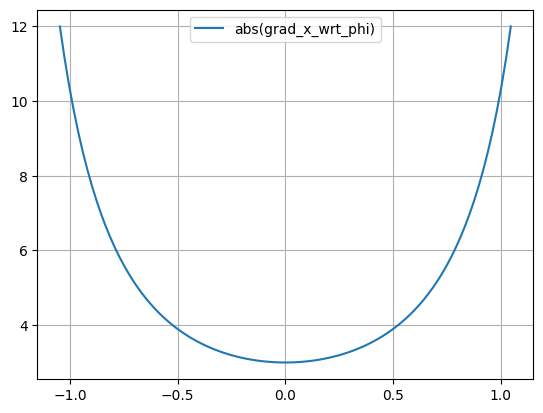

In [40]:
import matplotlib.pyplot as plt
import numpy as np

x0_val = 14
y0_val = 14
x_val = 9
y_val = 17

phi_vals = np.linspace(-np.pi / 3, np.pi / 3, 100)

sec2_phi = 1.0 + np.tan(phi_vals) ** 2
grad_x_wrt_phi = -(y_val - y0_val) * sec2_phi

plt.figure()
plt.plot(phi_vals, np.abs(grad_x_wrt_phi), label="abs(grad_x_wrt_phi)")
plt.grid()
plt.legend()
plt.show()